# PROJECT OBJECTIVE

Analyze sales performance across:

Regions
Product Categories
Time

Identify:

Best Performing Products
Worst Performing Products
Seasonality Trends
Business Opportunities

# IMPORT LIBRARIES

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

# LOAD DATASET

In [9]:
df=pd.read_csv( "D://Alfido Tech/SALES PERFORMANCE ANALYSIS/sales_dataset.csv",encoding="latin1")

In [10]:
#Preview

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


# DATA UNDERSTANDING

In [11]:
df.shape

(9800, 18)

In [12]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

# DATA CLEANING

Check missing values

In [14]:
df.isnull().sum()

Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

In [15]:
#Remove missing values

df=df.dropna()

In [16]:
#Remove duplicates

df=df.drop_duplicates()

In [17]:
#Verify

df.shape

(9789, 18)

# KPI CREATION

## Average Order Value

In [19]:
aov=df[ "Sales" ].mean() 
print( round( aov, 2 ) )

230.12


## Total Orders

In [20]:
print( df[ "Order_ID" ].nunique() )

4916


# FEATURE ENGINEERING

In [24]:
#Convert Date

df[
"Order_Date"
]=pd.to_datetime(
df[
"Order_Date"
],
    format='%d/%m/%Y'
)

In [29]:
#Create Month

df[
"Month"
]=df[
"Order_Date"
].dt.month

In [26]:
#Create Year

df[
"Year"
]=df[
"Order_Date"
].dt.year

In [27]:
#Check

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Month,Year
0,1,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,11,2017
1,2,CA-2017-152156,2017-11-08,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,11,2017
2,3,CA-2017-138688,2017-06-12,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,6,2017
3,4,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,10,2016
4,5,US-2016-108966,2016-10-11,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,10,2016


## Monthly Sales Trend Visualization

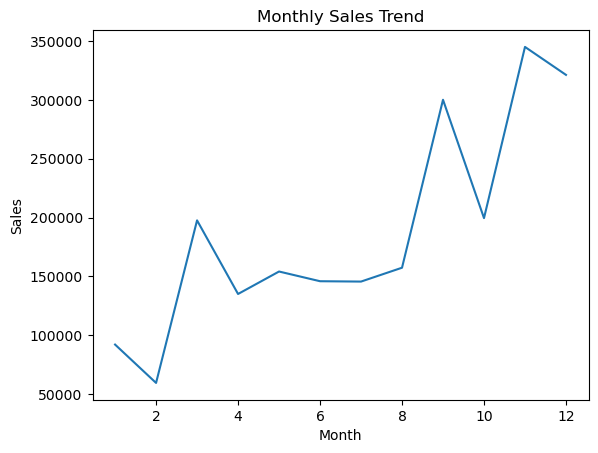

In [30]:
monthly=df.groupby( "Month" )[ "Sales" ].sum()
monthly.plot( kind="line" ) 
plt.title( "Monthly Sales Trend" ) 
plt.xlabel( "Month" )
plt.ylabel( "Sales" )
plt.show()

## Category Performance Visualization

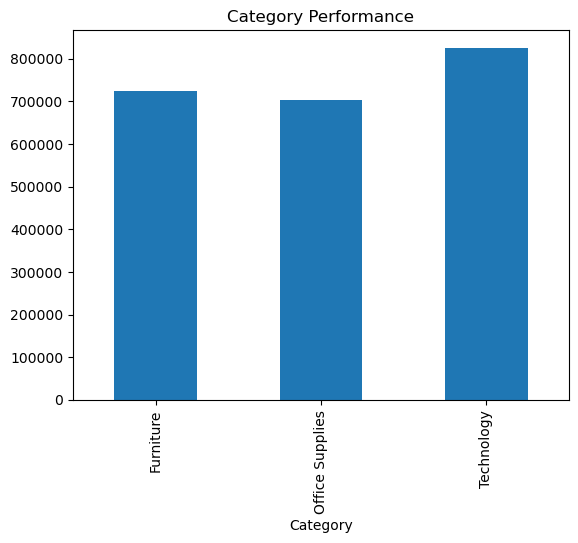

In [31]:
df.groupby(
"Category"
)[
"Sales"
].sum().plot(
kind="bar"
)

plt.title(
"Category Performance"
)

plt.show()

## Regional Performance Visualization

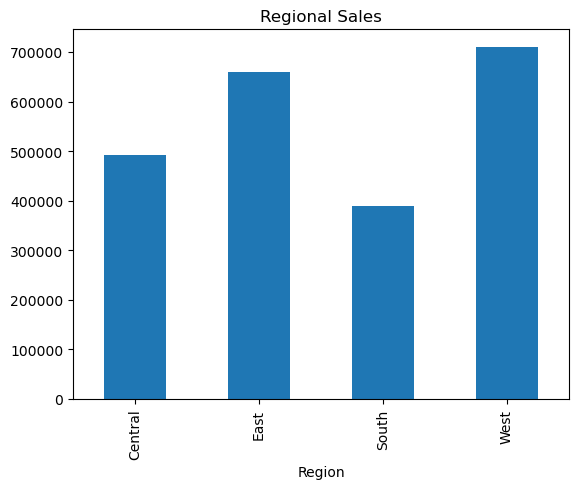

In [32]:
df.groupby( "Region" )[ "Sales" ].sum().plot( kind="bar" )
plt.title( "Regional Sales" )
plt.show()

## BEST & WORST PRODUCTS

In [33]:
#Top Products

top=df.groupby(
"Product_Name"
)[
"Sales"
].sum()

print(
top.sort_values(
ascending=False
).head(10)
)


Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [35]:
#Worst Products

print(
top.sort_values(
ascending=True
).head(10)
)

Product_Name
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac    1.624
Avery 5                                                             5.760
Xerox 20                                                            6.480
Grip Seal Envelopes                                                 7.072
Acme Serrated Blade Letter Opener                                   7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                  7.700
Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink     7.800
Xerox 1989                                                          7.968
Stockwell Gold Paper Clips                                          8.096
Acco Economy Flexible Poly Round Ring Binder                        8.352
Name: Sales, dtype: float64


## SEASONALITY ANALYSIS

In [39]:
season=df.groupby( "Month" )[ "Sales" ].sum() 
print( season )

Month
1      91982.1396
2      59371.1154
3     197573.5872
4     134988.2506
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    345041.6110
12    321275.1395
Name: Sales, dtype: float64


## KEY FINDINGS


## 5 TACTICAL IMPROVEMENTS FOR ALFIDO TECH

## EXECUTIVE SUMMARY